# Automated Mechanical Surface Inspection

**Computer Vision + Machine Learning + Deep Learning + Embedded Camera**

This notebook trains a surface-defect classifier using the **NEU Surface Defect Dataset** and provides:

- OpenCV image preprocessing
- CLAHE contrast enhancement
- Gaussian noise reduction
- Canny edge extraction
- Two-channel CNN input: enhanced image + edge map
- GPU training with PyTorch
- Stratified train/validation/test split
- Accuracy, precision, recall and F1-score
- Confusion matrix
- Class-wise defect analysis
- Test-image inspection output
- Optional camera-image inference for VS Code/local execution

> **Important:** The NEU dataset contains defect classes rather than a true "good/no-defect" class. Therefore this notebook reports classification performance and class-wise false-negative rates. A true manufacturing False Reject Rate requires adding a **defect-free/OK** class with representative good-part images.


In [3]:
# ==========================================
# 0. ENVIRONMENT SETUP
# ==========================================
import os
import sys
import zipfile
import urllib.request
import random
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch version:", torch.__version__)
print("Compute device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


PyTorch version: 2.11.0+cu128
Compute device: cuda
GPU: Tesla T4


## 1. Dataset Setup

The notebook downloads the **NEU Surface Defect Dataset**, which contains six steel-surface defect categories:

- crazing
- inclusion
- patches
- pitted surface
- rolled-in scale
- scratches


In [4]:
# ==========================================
# 1. DATASET DOWNLOAD
# ==========================================
import os
import zipfile
import urllib.request
from pathlib import Path

DATASET_URL = "https://github.com/Dabi0228/NEU-Surface-Defect-Dataset/archive/refs/heads/main.zip"

WORK_DIR = Path("./surface_inspection_data")
ZIP_PATH = WORK_DIR / "NEU-DET.zip"
EXTRACT_DIR = WORK_DIR / "dataset"

WORK_DIR.mkdir(parents=True, exist_ok=True)

def download_dataset():

    if EXTRACT_DIR.exists() and any(EXTRACT_DIR.rglob("*.jpg")):
        print("Dataset already available.")
        return

    print("Downloading NEU Surface Defect Dataset...")

    urllib.request.urlretrieve(DATASET_URL, ZIP_PATH)

    print("Extracting dataset...")

    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(EXTRACT_DIR)

    print("Dataset downloaded and extracted successfully.")

download_dataset()

Extracting dataset...
Dataset downloaded and extracted successfully.


In [5]:
# ==========================================
# 2. FIND AND LABEL IMAGES
# ==========================================
CLASSES = [
    "crazing",
    "inclusion",
    "patches",
    "pitted_surface",
    "rolled_in_scale",
    "scratches"
]

CLASS_TO_ID = {name: i for i, name in enumerate(CLASSES)}

def identify_class(path):
    text = str(path).lower().replace("-", "_").replace(" ", "_")

    # Check longer names first
    for class_name in sorted(CLASSES, key=len, reverse=True):
        if class_name in text:
            return class_name
    return None

records = []

for path in EXTRACT_DIR.rglob("*"):
    if path.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp"}:
        class_name = identify_class(path)
        if class_name is not None:
            records.append({
                "path": str(path),
                "class": class_name,
                "label": CLASS_TO_ID[class_name]
            })

df = pd.DataFrame(records)

if df.empty:
    raise RuntimeError(
        "No labelled images were found. Inspect the extracted dataset structure "
        "and update identify_class() if the dataset naming differs."
    )

print(f"Total images: {len(df)}")
print("\nImages per class:")
print(df["class"].value_counts().reindex(CLASSES))


Total images: 1800

Images per class:
class
crazing            300
inclusion          300
patches            300
pitted_surface     300
rolled_in_scale    300
scratches          300
Name: count, dtype: int64


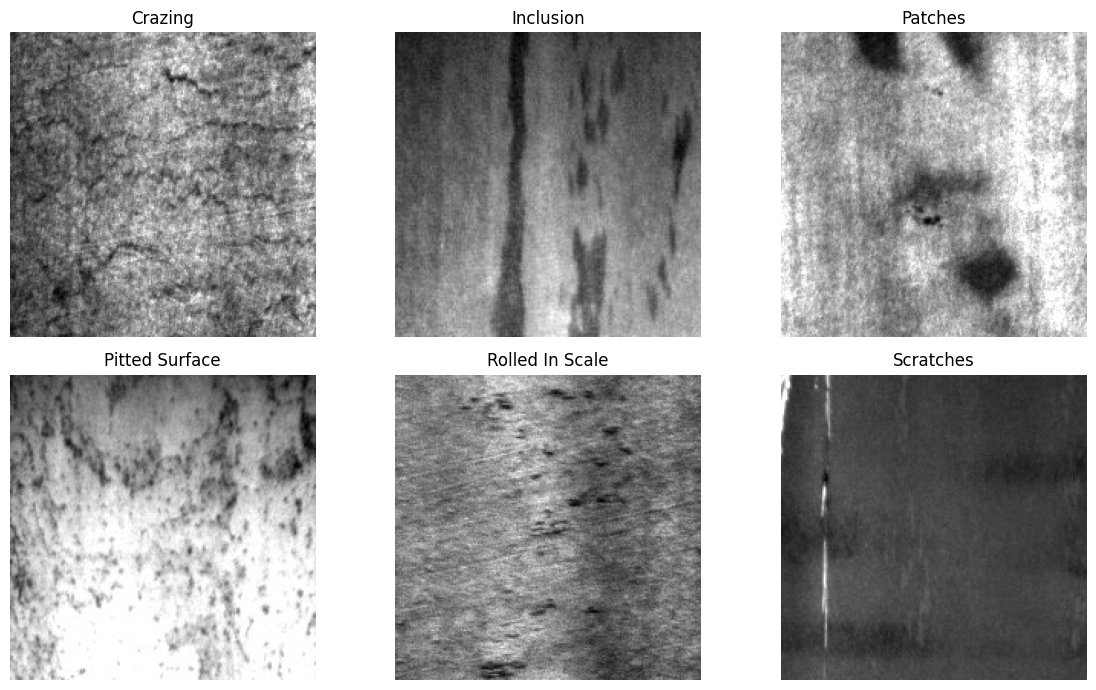

In [6]:
# ==========================================
# 3. DATASET VISUAL CHECK
# ==========================================
fig, axes = plt.subplots(2, 3, figsize=(12, 7))

for ax, class_name in zip(axes.ravel(), CLASSES):
    sample = df[df["class"] == class_name].sample(1, random_state=SEED).iloc[0]
    img = cv2.imread(sample["path"], cv2.IMREAD_GRAYSCALE)

    ax.imshow(img, cmap="gray")
    ax.set_title(class_name.replace("_", " ").title())
    ax.axis("off")

plt.tight_layout()
plt.show()


## 4. OpenCV Inspection Preprocessing

The camera image is converted into a representation useful for surface inspection:

**Camera image → grayscale → resize → CLAHE → Gaussian filtering → Canny edges**

The enhanced grayscale image and edge image are then supplied as two input channels to the CNN.


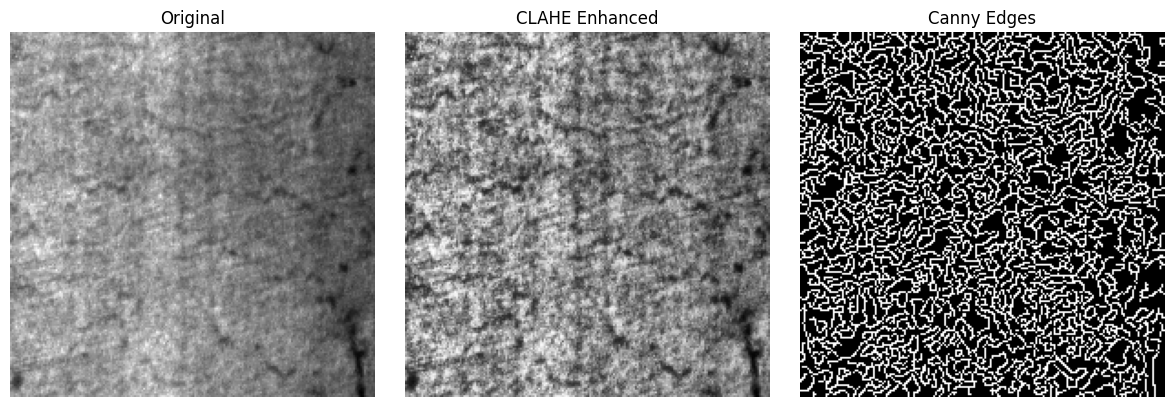

In [7]:
# ==========================================
# 4. OPENCV PREPROCESSING
# ==========================================
IMG_SIZE = 200

class SurfaceInspectorCV:

    @staticmethod
    def preprocess(img_path_or_frame):
        if isinstance(img_path_or_frame, (str, Path)):
            img = cv2.imread(str(img_path_or_frame), cv2.IMREAD_GRAYSCALE)
        else:
            if img_path_or_frame is None:
                raise ValueError("Invalid image/frame.")
            if len(img_path_or_frame.shape) == 3:
                img = cv2.cvtColor(img_path_or_frame, cv2.COLOR_BGR2GRAY)
            else:
                img = img_path_or_frame

        if img is None:
            raise ValueError("Could not read image.")

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        clahe = cv2.createCLAHE(
            clipLimit=2.0,
            tileGridSize=(8, 8)
        )
        enhanced = clahe.apply(img)

        blurred = cv2.GaussianBlur(
            enhanced,
            (5, 5),
            0
        )

        edges = cv2.Canny(
            blurred,
            50,
            150
        )

        return enhanced, edges


sample_path = df.iloc[0]["path"]
original = cv2.imread(sample_path, cv2.IMREAD_GRAYSCALE)
enhanced, edges = SurfaceInspectorCV.preprocess(sample_path)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(cv2.resize(original, (IMG_SIZE, IMG_SIZE)), cmap="gray")
axes[0].set_title("Original")

axes[1].imshow(enhanced, cmap="gray")
axes[1].set_title("CLAHE Enhanced")

axes[2].imshow(edges, cmap="gray")
axes[2].set_title("Canny Edges")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()


## 5. Stratified Train / Validation / Test Split

A stratified split keeps the six defect classes represented across the three subsets.

This is preferable to simply taking the first 80% of files because the dataset may be ordered by class.


In [8]:
# ==========================================
# 5. STRATIFIED DATA SPLIT
# ==========================================
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

split_table = pd.DataFrame({
    "Train": train_df["class"].value_counts().reindex(CLASSES),
    "Validation": val_df["class"].value_counts().reindex(CLASSES),
    "Test": test_df["class"].value_counts().reindex(CLASSES)
})

display(split_table)


Train: 1260
Validation: 270
Test: 270


,Train,Validation,Test
class,,,
crazing,210,45,45
inclusion,210,45,45
patches,210,45,45
pitted_surface,210,45,45
rolled_in_scale,210,45,45
scratches,210,45,45


In [9]:
# ==========================================
# 6. PYTORCH DATASET
# ==========================================
class SurfaceDefectDataset(Dataset):

    def __init__(self, dataframe):
        self.dataframe = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        enhanced, edges = SurfaceInspectorCV.preprocess(row["path"])

        combined = np.stack(
            [enhanced, edges],
            axis=0
        ).astype(np.float32) / 255.0

        image = torch.from_numpy(combined)
        label = torch.tensor(
            row["label"],
            dtype=torch.long
        )

        return image, label


BATCH_SIZE = 32

train_ds = SurfaceDefectDataset(train_df)
val_ds = SurfaceDefectDataset(val_df)
test_ds = SurfaceDefectDataset(test_df)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=(device.type == "cuda")
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=(device.type == "cuda")
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=(device.type == "cuda")
)

sample_batch, sample_labels = next(iter(train_loader))

print("Input tensor shape:", sample_batch.shape)
print("Label shape:", sample_labels.shape)


Input tensor shape: torch.Size([32, 2, 200, 200])
Label shape: torch.Size([32])


In [10]:
# ==========================================
# 7. CNN MODEL
# ==========================================
class SurfaceInspectionCNN(nn.Module):

    def __init__(self, num_classes=6):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(2, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


model = SurfaceInspectionCNN(
    num_classes=len(CLASSES)
).to(device)

print(model)


SurfaceInspectionCNN(
  (features): Sequential(
    (0): Conv2d(2, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_sta

In [11]:
# ==========================================
# 8. TRAINING
# ==========================================
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3
)

EPOCHS = 15

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

def run_epoch(loader, training=True):

    if training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(training):
            outputs = model(images)
            loss = criterion(outputs, labels)

            if training:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * labels.size(0)

        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


best_val_acc = 0.0
best_state = None

for epoch in range(EPOCHS):

    train_loss, train_acc = run_epoch(
        train_loader,
        training=True
    )

    val_loss, val_acc = run_epoch(
        val_loader,
        training=False
    )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = {
            k: v.detach().cpu().clone()
            for k, v in model.state_dict().items()
        }

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc*100:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc*100:.2f}%"
    )

if best_state is not None:
    model.load_state_dict(best_state)

print(f"\nBest validation accuracy: {best_val_acc*100:.2f}%")


Epoch 01/15 | Train Loss: 0.8617 | Train Acc: 72.14% | Val Loss: 0.7669 | Val Acc: 70.74%
Epoch 02/15 | Train Loss: 0.5259 | Train Acc: 84.60% | Val Loss: 0.3890 | Val Acc: 87.78%
Epoch 03/15 | Train Loss: 0.4303 | Train Acc: 86.83% | Val Loss: 0.9203 | Val Acc: 76.67%
Epoch 04/15 | Train Loss: 0.3641 | Train Acc: 89.44% | Val Loss: 0.2932 | Val Acc: 92.59%
Epoch 05/15 | Train Loss: 0.2932 | Train Acc: 91.35% | Val Loss: 0.3333 | Val Acc: 89.26%
Epoch 06/15 | Train Loss: 0.2704 | Train Acc: 91.90% | Val Loss: 0.2050 | Val Acc: 94.07%
Epoch 07/15 | Train Loss: 0.2506 | Train Acc: 93.10% | Val Loss: 0.2315 | Val Acc: 92.59%
Epoch 08/15 | Train Loss: 0.2212 | Train Acc: 93.17% | Val Loss: 0.1816 | Val Acc: 94.44%
Epoch 09/15 | Train Loss: 0.1897 | Train Acc: 93.97% | Val Loss: 0.2054 | Val Acc: 94.44%
Epoch 10/15 | Train Loss: 0.1887 | Train Acc: 94.13% | Val Loss: 0.2017 | Val Acc: 94.44%
Epoch 11/15 | Train Loss: 0.1708 | Train Acc: 94.52% | Val Loss: 0.2145 | Val Acc: 92.96%
Epoch 12/1

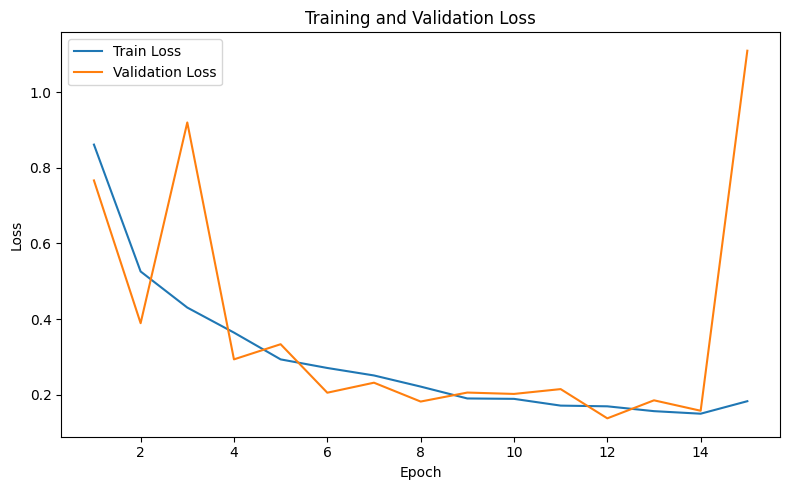

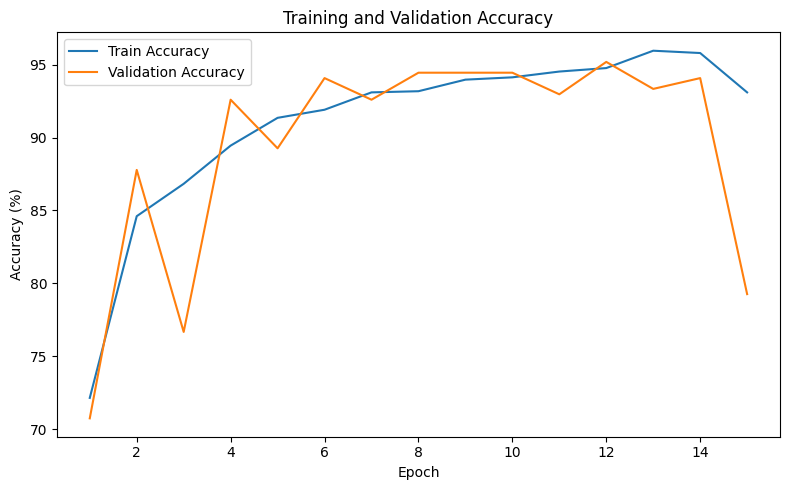

In [12]:
# ==========================================
# 9. TRAINING CURVES
# ==========================================
epochs = range(1, EPOCHS + 1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(epochs, history["train_loss"], label="Train Loss")
ax.plot(epochs, history["val_loss"], label="Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training and Validation Loss")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(epochs, np.array(history["train_acc"]) * 100, label="Train Accuracy")
ax.plot(epochs, np.array(history["val_acc"]) * 100, label="Validation Accuracy")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Training and Validation Accuracy")
ax.legend()
plt.tight_layout()
plt.show()


In [13]:
# ==========================================
# 10. TEST SET EVALUATION
# ==========================================
model.eval()

y_true = []
y_pred = []
y_prob = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)
        probabilities = torch.softmax(outputs, dim=1)
        predictions = outputs.argmax(dim=1)

        y_true.extend(labels.numpy())
        y_pred.extend(predictions.cpu().numpy())
        y_prob.extend(probabilities.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

accuracy = accuracy_score(y_true, y_pred)

precision, recall, f1, support = precision_recall_fscore_support(
    y_true,
    y_pred,
    labels=np.arange(len(CLASSES)),
    zero_division=0
)

print(f"Test Accuracy: {accuracy*100:.2f}%")
print()

print(classification_report(
    y_true,
    y_pred,
    target_names=[c.replace("_", " ").title() for c in CLASSES],
    zero_division=0
))


Test Accuracy: 97.41%

                 precision    recall  f1-score   support

        Crazing       0.98      1.00      0.99        45
      Inclusion       0.92      1.00      0.96        45
        Patches       1.00      0.98      0.99        45
 Pitted Surface       1.00      0.89      0.94        45
Rolled In Scale       1.00      1.00      1.00        45
      Scratches       0.96      0.98      0.97        45

       accuracy                           0.97       270
      macro avg       0.98      0.97      0.97       270
   weighted avg       0.98      0.97      0.97       270



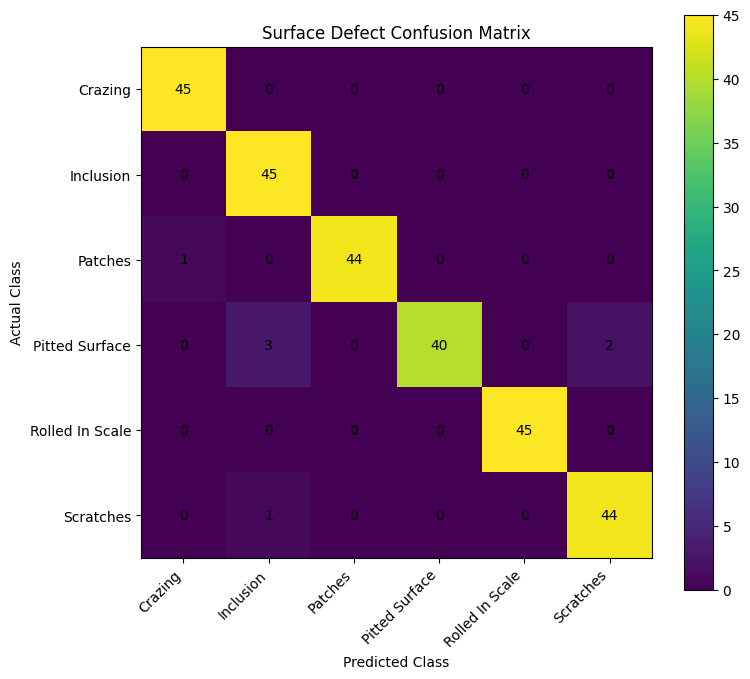

,Class,Precision,Recall,F1 Score,False Negative Rate,Samples
0,Crazing,0.9783,1.0000,0.9890,0.0000,45
1,Inclusion,0.9184,1.0000,0.9574,0.0000,45
2,Patches,1.0000,0.9778,0.9888,0.0222,45
3,Pitted Surface,1.0000,0.8889,0.9412,0.1111,45
4,Rolled In Scale,1.0000,1.0000,1.0000,0.0000,45
5,Scratches,0.9565,0.9778,0.9670,0.0222,45


Macro F1: 0.9739
Macro False Negative Rate: 0.0259


In [14]:
# ==========================================
# 11. CONFUSION MATRIX + CLASS-WISE METRICS
# ==========================================
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=np.arange(len(CLASSES))
)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm)

ax.set_xticks(range(len(CLASSES)))
ax.set_yticks(range(len(CLASSES)))

display_names = [
    c.replace("_", " ").title()
    for c in CLASSES
]

ax.set_xticklabels(display_names, rotation=45, ha="right")
ax.set_yticklabels(display_names)

for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        ax.text(j, i, cm[i, j], ha="center", va="center")

ax.set_xlabel("Predicted Class")
ax.set_ylabel("Actual Class")
ax.set_title("Surface Defect Confusion Matrix")

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

metrics_df = pd.DataFrame({
    "Class": display_names,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "False Negative Rate": 1 - recall,
    "Samples": support
})

display(metrics_df.round(4))

print(
    f"Macro F1: {f1.mean():.4f}\n"
    f"Macro False Negative Rate: {(1 - recall).mean():.4f}"
)


## 12. Automated Inspection Output

The following cell runs the trained model on unseen test images and produces an inspection-style result containing:

- predicted defect type
- confidence
- source image

This is the software-side equivalent of receiving a frame from the embedded camera.


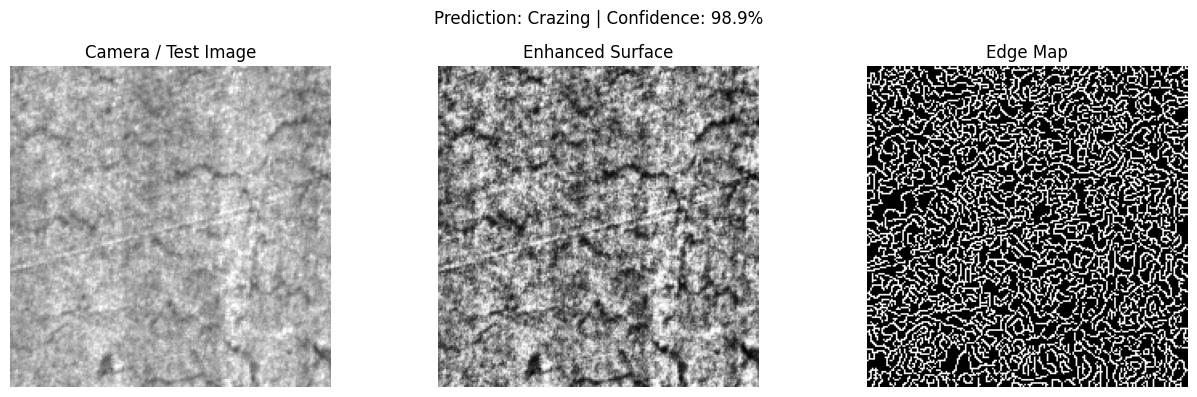

Predicted defect: crazing
Confidence: 98.85%


In [15]:
# ==========================================
# 12. TEST IMAGE INSPECTION
# ==========================================
def inspect_image(img_path, model=model, show_processing=True):

    model.eval()

    enhanced, edges = SurfaceInspectorCV.preprocess(img_path)

    combined = np.stack(
        [enhanced, edges],
        axis=0
    ).astype(np.float32) / 255.0

    tensor = torch.from_numpy(combined).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(tensor)
        probabilities = torch.softmax(output, dim=1)
        confidence, prediction = probabilities.max(dim=1)

    predicted_class = CLASSES[prediction.item()]
    confidence_percent = confidence.item() * 100

    original = cv2.imread(str(img_path))

    if show_processing:
        fig, axes = plt.subplots(1, 3, figsize=(13, 4))

        axes[0].imshow(
            cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
        )
        axes[0].set_title("Camera / Test Image")

        axes[1].imshow(enhanced, cmap="gray")
        axes[1].set_title("Enhanced Surface")

        axes[2].imshow(edges, cmap="gray")
        axes[2].set_title("Edge Map")

        for ax in axes:
            ax.axis("off")

        plt.suptitle(
            f"Prediction: {predicted_class.replace('_', ' ').title()} "
            f"| Confidence: {confidence_percent:.1f}%"
        )

        plt.tight_layout()
        plt.show()

    return predicted_class, confidence_percent


test_sample = test_df.sample(1, random_state=SEED).iloc[0]["path"]

prediction, confidence = inspect_image(test_sample)

print("Predicted defect:", prediction)
print(f"Confidence: {confidence:.2f}%")


In [16]:
# ==========================================
# 13. BATCH INSPECTION OUTPUT
# ==========================================
results = []

for _, row in test_df.sample(
    min(20, len(test_df)),
    random_state=SEED
).iterrows():

    prediction, confidence = inspect_image(
        row["path"],
        show_processing=False
    )

    results.append({
        "Image": Path(row["path"]).name,
        "Actual": row["class"],
        "Predicted": prediction,
        "Confidence (%)": round(confidence, 2),
        "Correct": prediction == row["class"]
    })

inspection_results = pd.DataFrame(results)

display(inspection_results)

print(
    "Batch accuracy:",
    f"{inspection_results['Correct'].mean()*100:.2f}%"
)


,Image,Actual,Predicted,Confidence (%),Correct
0,crazing_228.jpg,crazing,crazing,98.85,True
1,scratches_247.jpg,scratches,scratches,70.92,True
2,patches_160.jpg,patches,patches,60.96,True
3,scratches_57.jpg,scratches,scratches,65.56,True
4,inclusion_120.jpg,inclusion,inclusion,65.52,True
5,pitted_surface_40.jpg,pitted_surface,pitted_surface,99.84,True
6,patches_29.jpg,patches,patches,99.94,True
7,patches_67.jpg,patches,patches,83.34,True
8,pitted_surface_28.jpg,pitted_surface,pitted_surface,98.17,True
9,inclusion_125.jpg,inclusion,inclusion,88.64,True


Batch accuracy: 100.00%


## 14. Save the Trained Model

The saved model can later be used by a separate camera-inference application.

For an embedded deployment project, the next step would be to convert/optimize the trained model for the target hardware rather than retraining it on the device.


In [17]:
# ==========================================
# 14. SAVE MODEL
# ==========================================
MODEL_DIR = Path("./models")
MODEL_DIR.mkdir(exist_ok=True)

MODEL_PATH = MODEL_DIR / "surface_inspection_cnn.pth"

torch.save({
    "model_state_dict": model.state_dict(),
    "classes": CLASSES,
    "image_size": IMG_SIZE
}, MODEL_PATH)

print("Model saved to:", MODEL_PATH)


Model saved to: models/surface_inspection_cnn.pth


## 15. Optional Local Camera Inference — VS Code

This cell is intended for **local VS Code/Jupyter execution**, not standard Colab.

It reads frames from a webcam, runs the same preprocessing and trained CNN, and displays the predicted defect.

For an actual **ESP32-CAM** setup, the same inference function can later receive a JPEG frame from the ESP32-CAM instead of `cv2.VideoCapture(0)`.

> Do not use this cell in Colab unless you have specifically configured browser/webcam capture.


In [18]:
# ==========================================
# 15. OPTIONAL LOCAL WEBCAM INFERENCE
# ==========================================
# Run this only in VS Code/local Jupyter with a connected camera.
#
# Press 'q' to stop.

def preprocess_frame_for_model(frame):
    enhanced, edges = SurfaceInspectorCV.preprocess(frame)

    combined = np.stack(
        [enhanced, edges],
        axis=0
    ).astype(np.float32) / 255.0

    return torch.from_numpy(combined).unsqueeze(0)


def run_local_camera(model=model, camera_index=0):

    cap = cv2.VideoCapture(camera_index)

    if not cap.isOpened():
        raise RuntimeError("Could not open camera.")

    model.eval()

    while True:

        ret, frame = cap.read()

        if not ret:
            break

        input_tensor = preprocess_frame_for_model(frame).to(device)

        with torch.no_grad():
            output = model(input_tensor)
            probability = torch.softmax(output, dim=1)
            confidence, prediction = probability.max(dim=1)

        label = CLASSES[prediction.item()]
        conf = confidence.item() * 100

        text = (
            f"Inspection: "
            f"{label.replace('_', ' ').upper()} "
            f"({conf:.1f}%)"
        )

        cv2.putText(
            frame,
            text,
            (20, 40),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (0, 255, 0),
            2
        )

        cv2.imshow(
            "Mechanical Surface Inspection",
            frame
        )

        if cv2.waitKey(1) & 0xFF == ord("q"):
            break

    cap.release()
    cv2.destroyAllWindows()

# Uncomment for local execution:
# run_local_camera(model)


# Project Pipeline

```text
Mechanical Surface
       ↓
Embedded Camera
       ↓
Image Frame
       ↓
OpenCV Preprocessing
       ├── CLAHE
       ├── Gaussian Filtering
       └── Canny Edges
       ↓
2-Channel CNN
       ↓
Defect Classification
       ↓
Confidence + Quality Metrics
       ↓
Inspection Decision
```

### Current project scope

**Training:** Google Colab GPU or local GPU/CPU  
**Vision:** OpenCV  
**Model:** PyTorch CNN  
**Input:** Camera/surface image  
**Output:** Defect class + confidence  
**Evaluation:** Accuracy, precision, recall, F1, confusion matrix, false-negative rate  
**Embedded path:** ESP32-CAM → image frame → inference application

For a true manufacturing inspection system, add a **GOOD/OK class** and controlled camera/lighting conditions. This enables meaningful false-reject/false-accept analysis and makes the project closer to an actual inspection workflow.
